In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def var(populacao):
  media = populacao.mean()
  soma = 0
  for x in populacao:
    soma= soma + (x-media)**2
  return soma/len(populacao)


def varam(amostra):
  media = amostra.mean()
  soma = 0
  for x in amostra:
    soma = soma +(x-media)**2
  return soma/(len(amostra)-1)

def dp(populacao):
  return var(populacao)**(0.5)


def dpam(amostra):
  return varam(amostra)**(0.5)

Dp pop:  2.8722813232690143


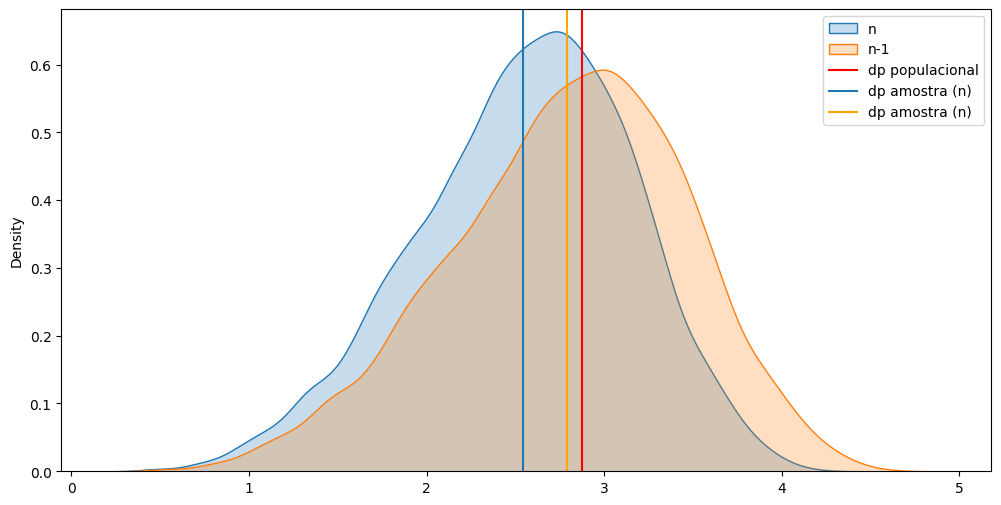

DP amostra (var):  2.5449537701479246
DP amostra (varam):  2.787857175435672


In [6]:
pop = np.arange(1,11)


print("Dp pop: ", dp(pop))

# como é nossa população: [1,2,3,4,5,6,7,8,9,10]


n_simulacoes = 10000

desvios_n = []
desvios_nmenos1 = []


n_amostra=6
for _ in range(n_simulacoes):
  amos = np.random.choice(pop, n_amostra, replace=True)
  desvios_n.append(amos.std(ddof=0))
  desvios_nmenos1.append(amos.std(ddof=1))


plt.figure( figsize=(12,6) )

sns.kdeplot(desvios_n, label="n", fill=True)
sns.kdeplot(desvios_nmenos1, label="n-1", fill=True)

plt.axvline(x=dp(pop), label="dp populacional", color='red')
plt.axvline(x=np.array(desvios_n).mean(), label="dp amostra (n)")
plt.axvline(x=np.array(desvios_nmenos1).mean(), label="dp amostra (n)", color='orange')
plt.legend()
plt.show()

print("DP amostra (var): ", np.array(desvios_n).mean())

print("DP amostra (varam): ", np.array(desvios_nmenos1).mean())



In [ ]:
pop = [20,30,40]

n_amostra=2

# [20,30,40] => (20-30)^2 + 30-30 + (40-30)^2

# 0-9
# 0-9

# pop = [20,30,40]
#            n      n-1
# [20,20] => 0      0   (20-20)^2 + (20-20)^2 -> 0 / n n-1
# [20,30] => 25     50   (20-25)^2 + (30-25)^2 -> 50 / 2 1
# [20,40] => 100    200   (20-30)^2 + (40-30)^2 -> 200
# [30,20] => 25     50
# [30,30] => 0      0
# [30,40] => 25     50
# [40,20] => 100    200
# [40,30] => 25     50
# [40,40] => 0      0

print(300/9)
print(600/9)
print(200/3)

33.333333333333336
66.66666666666667
66.66666666666667


In [ ]:
np.random.choice(pop, [100000,4], replace=True)

array([[ 1,  5,  9,  5],
       [ 5,  9,  2,  4],
       [ 5,  2,  4,  1],
       ...,
       [ 6,  8, 10,  7],
       [ 2,  3,  8,  3],
       [10,  3,  5,  7]])

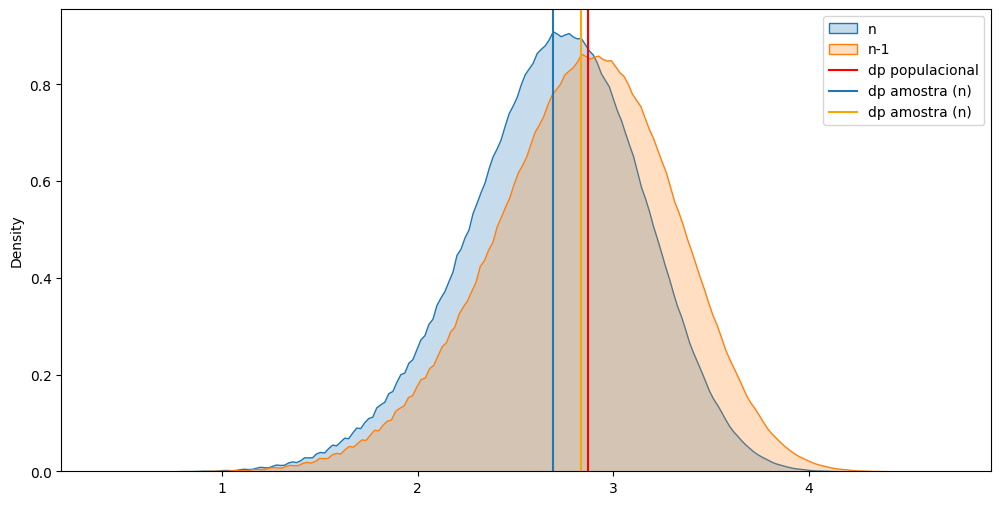

Dp pop:  2.8722813232690143
DP amostra (ddof=0):  2.6888109930712667
DP amostra (ddof=1):  2.8342556452681444


In [32]:
pop = np.arange(1,11)

# como é nossa população: [1,2,3,4,5,6,7,8,9,10]


desvios_n = []
desvios_nmenos1 = []

n_simulacoes=4000000
n_amostra=10

amos = np.random.choice(pop, [n_simulacoes,n_amostra], replace=True)

std0=amos.std(axis=1,ddof=0)
std1=amos.std(axis=1,ddof=1)
std0mean=std0.mean()
std1mean=std1.mean()


plt.figure( figsize=(12,6) )

sns.kdeplot(std0, label="n", fill=True)
sns.kdeplot(std1, label="n-1", fill=True)

plt.axvline(x=pop.std(), label="dp populacional", color='red')
plt.axvline(x=std0mean, label="dp amostra (n)")
plt.axvline(x=std1mean, label="dp amostra (n)", color='orange')
plt.legend()
plt.show()

print("Dp pop: ", pop.std())
print("DP amostra (ddof=0): ", std0mean)

print("DP amostra (ddof=1): ", std1mean)



np.float64(2.872537838709163)